# 🧑‍💼 Synthetic Employee Data Analysis
Exploratory Analysis and Black-Box Evaluation of Peer-Generated Data

## 📋 Project Information
**Course:** ALDA - Algorithm Analysis and Data Analysis

**Student:** Geronimo Martinez Nuñez

**Task:** Peer Data Analysis (20%)

**Description:** Black-box analysis of synthetic data generated by a classmate

**Date:** March 2026

---

# 🔧 Setup & Imports

Loading required libraries for data manipulation, visualization, and clustering.

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Exploratory Data Analysis: Small vs Big Dataset

     employee_id first_name last_name                       email  \
0  EMP3479083960       Jack     Blair      jack.blair@company.com   
1  EMP2751653872        Amy      Barr        amy.barr@company.com   
2  EMP1912875758        Ian      Rice        ian.rice@company.com   
3  EMP9386314585   Cristian     Jones  cristian.jones@company.com   
4  EMP1214237725      Tammy   Osborne   tammy.osborne@company.com   

            phone_number        department               job_title  \
0       241.926.2177x652       Engineering     Mechanical Engineer   
1       001-406-281-8295                IT        Network Engineer   
2        +1-525-870-6793       Engineering        Systems Engineer   
3  +1-823-701-1357x40186  Customer Service  Call Center Supervisor   
4             3393397367             Legal        Corporate Lawyer   

    hire_date  days_service  base_salary  ...  performance_score  \
0  2022-05-12          1065     65242.57  ...              72.11   
1  2024-12-02           130 

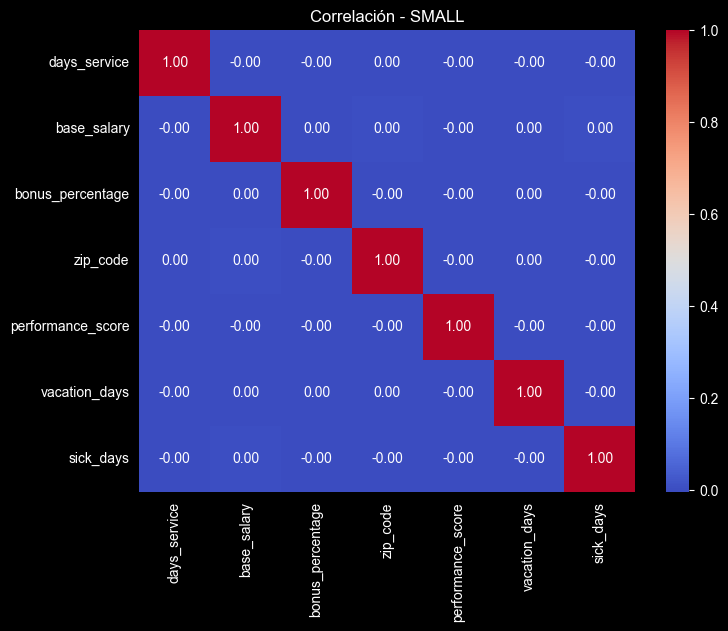


===== SAMPLE BIG (CHUNKS) =====
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   days_service       200000 non-null  int64  
 1   base_salary        200000 non-null  float64
 2   bonus_percentage   200000 non-null  float64
 3   zip_code           200000 non-null  int64  
 4   performance_score  200000 non-null  float64
 5   vacation_days      200000 non-null  int64  
 6   sick_days          200000 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 10.7 MB
None
        days_service    base_salary  bonus_percentage       zip_code  \
count  200000.000000  200000.000000     200000.000000  200000.000000   
mean      913.673545   67016.938243          5.005835   50380.728325   
std       527.650408   25695.586085          1.994130   28758.909762   
min         1.000000   30000.000000          0.000000     501.000000   
25%       4

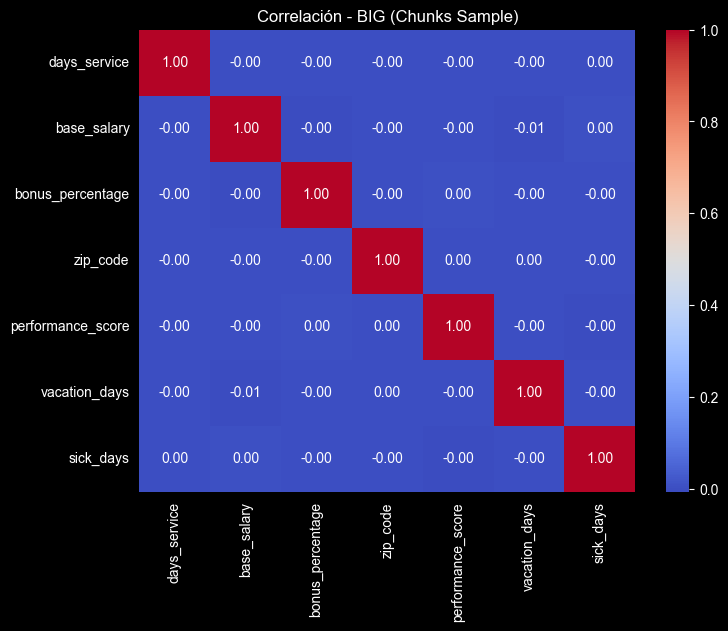

In [3]:
path_big = Path('../data/data13_big.csv')
path_small = Path('../data/data13_Small.csv')

# =========================
# dataset small
# =========================
df_small = pd.read_csv(path_small)
print(df_small.head())
print(df_small.info())
print(df_small.describe())
corr_small = df_small.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr_small, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlación - SMALL")
plt.show()


# =========================
# dataset big
# =========================
chunksize = 100000
sample_per_chunk = 2000
df_sample = []

for i, chunk in enumerate(pd.read_csv(path_big, chunksize=chunksize)):
    chunk_num = chunk.select_dtypes(include=['int64', 'float64'])
    if len(chunk_num) > sample_per_chunk:
        chunk_sample = chunk_num.sample(sample_per_chunk, random_state=42)
    else:
        chunk_sample = chunk_num

    df_sample.append(chunk_sample)

df_big_sample = pd.concat(df_sample, ignore_index=True)

print("\n===== SAMPLE BIG (CHUNKS) =====")
print(df_big_sample.info())
print(df_big_sample.describe())
corr_big = df_big_sample.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_big, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlación - BIG (Chunks Sample)")
plt.show()


# 📊 Exploratory Data Analysis

## 🧾 Dataset Structure

The dataset contains **30 columns**, with the following data types:

### 📌 Columns and Data Types

| Column              | Data Type |
|--------------------|----------|
| employee_id        | string   |
| first_name         | string   |
| last_name          | string   |
| email              | string   |
| phone_number       | string   |
| department         | string   |
| job_title          | string   |
| hire_date          | string   |
| days_service       | int64    |
| base_salary        | float64  |
| bonus_percentage   | float64  |
| status             | string   |
| birth_date         | string   |
| address            | string   |
| city               | string   |
| state              | string   |
| zip_code           | int64    |
| country            | string   |
| gender             | string   |
| education          | string   |
| performance_score  | float64  |
| last_review_date   | string   |
| employee_level     | string   |
| vacation_days      | int64    |
| sick_days          | int64    |
| work_location      | string   |
| shift              | string   |
| emergency_contact  | string   |
| ssn                | string   |
| bank_account       | string   |

---

## 📈 Correlation Analysis

A correlation analysis was performed on the numerical variables of the dataset using a correlation matrix and a heatmap.

### 🔍 Results

- All observed correlations are close to **0**.
- No significant linear relationships were identified between any of the numerical variables.

---

## ⚠️ Conclusions

- There is no correlation between numerical variables, which is unusual in real-world data.
- In real scenarios, relationships such as the following would be expected:
  - More experience (days_service) → higher salary (base_salary)
  - Better performance (performance_score) → higher bonus (bonus_percentage)
- The complete absence of correlation suggests that the variables were generated independently.
- The data distributions appear artificially clean, with well-defined means and standard deviations.
- The large size of the dataset (1,000,000 records) and the consistent structure of personal data (names, emails, etc.) reinforce the hypothesis that the data is synthetic.

# Exploratory Data Analysis — String Dataset


===== IDENTIFIER COLUMNS ANALYSIS =====

Column: employee_id
Unique ratio: 1.0000
Sample values: ['EMP3479083960', 'EMP2751653872', 'EMP1912875758']

Column: email
Unique ratio: 0.2975
Sample values: ['jack.blair@company.com', 'amy.barr@company.com', 'ian.rice@company.com']

Column: ssn
Unique ratio: 0.9995
Sample values: ['547-45-5420', '058-99-6618', '106-04-2587']

Column: bank_account
Unique ratio: 1.0000
Sample values: ['MRMJ65602129091077', 'MZQB33495882532222', 'LXRC21496855902331']

Column: phone_number
Unique ratio: 1.0000
Sample values: ['241.926.2177x652', '001-406-281-8295', '+1-525-870-6793']

===== ANALYZING: DEPARTMENT =====
Top categories (%):
department
Security            5.2871
Design              5.2870
R&D                 5.2841
Research            5.2821
Logistics           5.2819
Customer Service    5.2684
Quality             5.2669
Procurement         5.2654
HHRR                5.2619
Sales               5.2613
Name: proportion, dtype: float64
Total unique valu

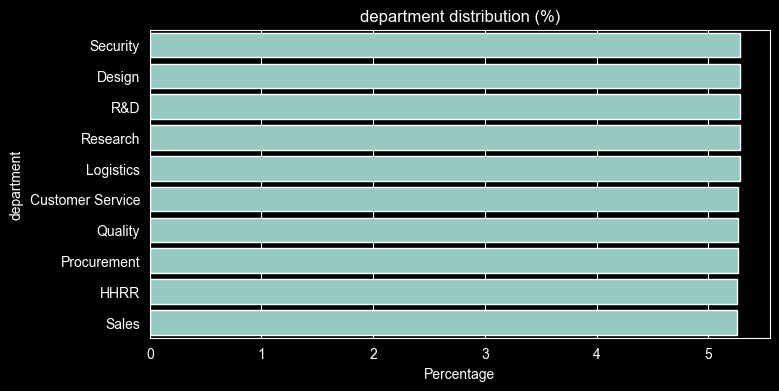


===== ANALYZING: JOB_TITLE =====
Top categories (%):
job_title
Security Manager                  1.3417
Client Relations Manager          1.3397
Research Scientist                1.3375
Process Improvement Specialist    1.3360
Logistics Manager                 1.3330
Supply Chain Analyst              1.3324
UX/UI Designer                    1.3317
Quality Control Inspector         1.3306
Product Development Engineer      1.3270
Industrial Designer               1.3261
Name: proportion, dtype: float64
Total unique values: 84


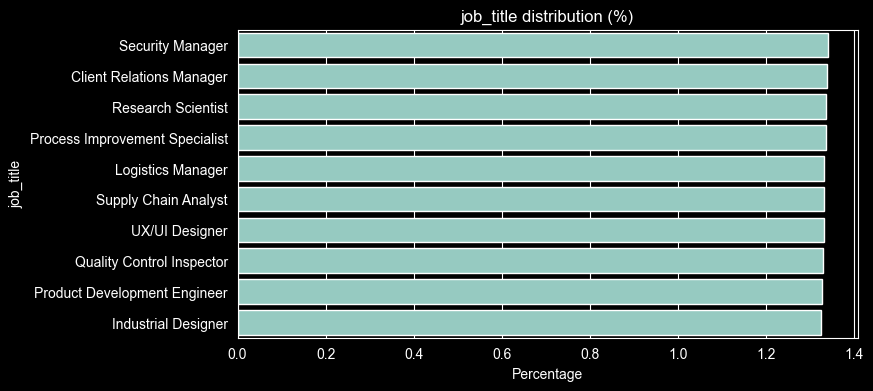


===== ANALYZING: STATUS =====
Top categories (%):
status
Active      84.9831
Inactive    10.0459
Leave        4.9710
Name: proportion, dtype: float64
Total unique values: 3


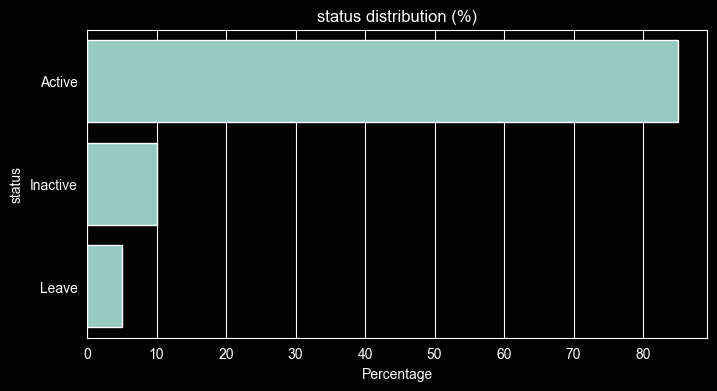


===== ANALYZING: GENDER =====
Top categories (%):
gender
F        44.9924
M        44.9839
Other    10.0237
Name: proportion, dtype: float64
Total unique values: 3


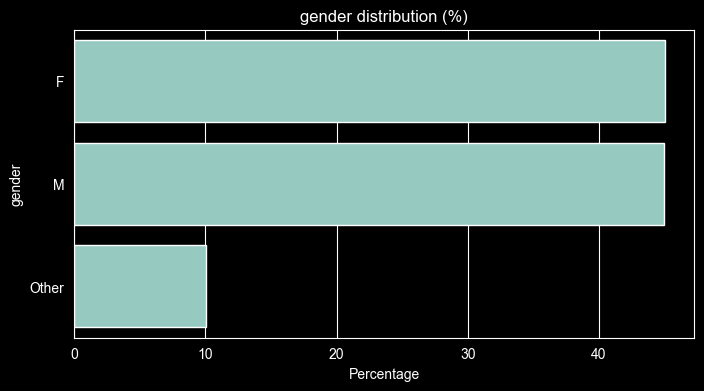


===== ANALYZING: EDUCATION =====
Top categories (%):
education
Professional    49.9759
Master          25.0352
High School     19.9868
PhD              5.0021
Name: proportion, dtype: float64
Total unique values: 4


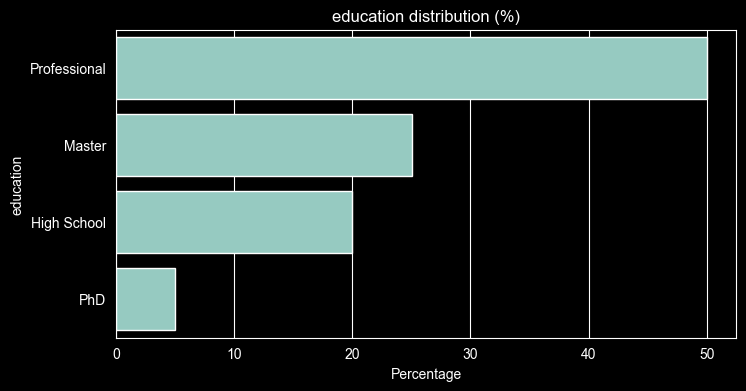


===== ANALYZING: EMPLOYEE_LEVEL =====
Top categories (%):
employee_level
Senior    60.0314
Mid       20.0804
Entry     19.8882
Name: proportion, dtype: float64
Total unique values: 3


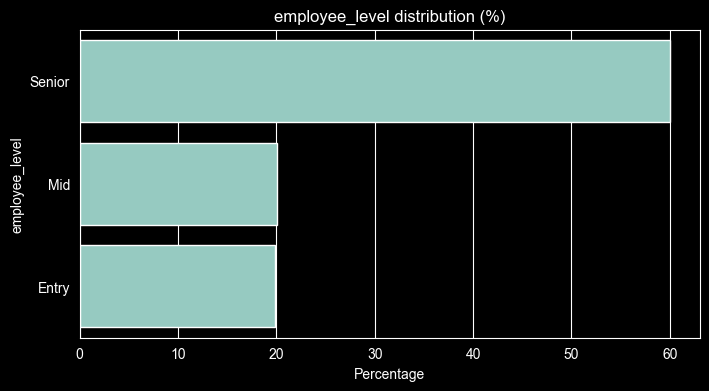


===== ANALYZING: WORK_LOCATION =====
Top categories (%):
work_location
Office    49.9709
Remote    30.0087
Hybrid    20.0204
Name: proportion, dtype: float64
Total unique values: 3


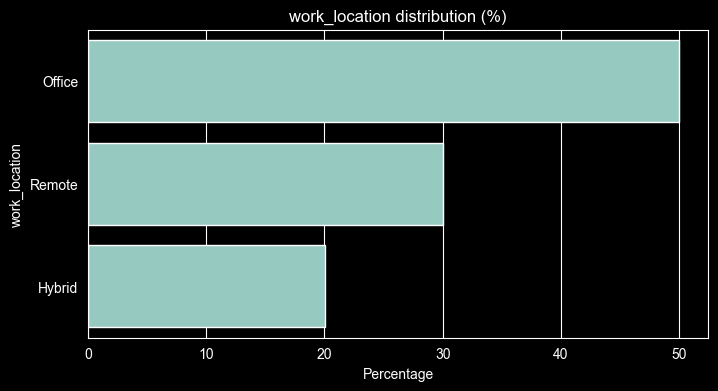


===== ANALYZING: SHIFT =====
Top categories (%):
shift
Day         60.0542
Night       29.9778
Flexible     9.9680
Name: proportion, dtype: float64
Total unique values: 3


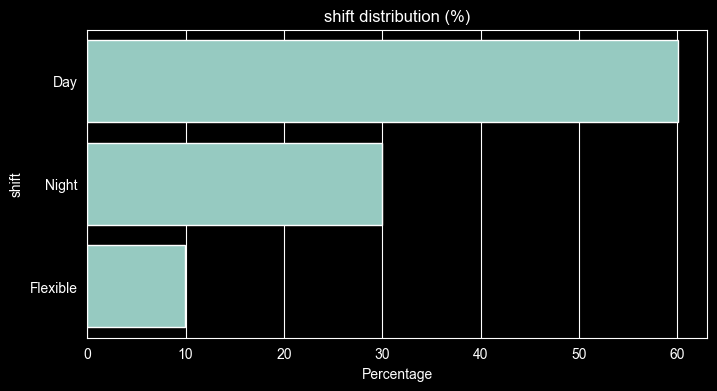


===== ANALYZING: COUNTRY =====
Top categories (%):
country
USA    100.0
Name: proportion, dtype: float64
Total unique values: 1


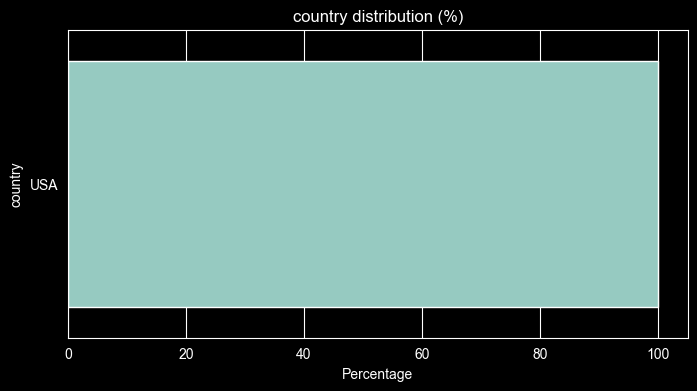


===== ANALYZING: STATE =====
Top categories (%):
state
TX    10.0606
NY    10.0376
FL    10.0355
OH    10.0104
MA    10.0101
WA     9.9833
CA     9.9832
GA     9.9679
PA     9.9587
IL     9.9527
Name: proportion, dtype: float64
Total unique values: 10


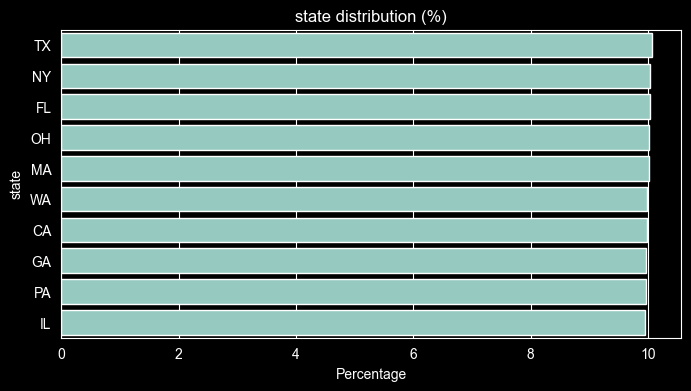


===== TEXT COLUMNS ANALYSIS =====

Column: first_name
Unique values: 690
Top 10 most frequent values:
first_name
Michael        22614
David          15546
James          14762
John           14593
Jennifer       14516
Christopher    13906
Robert         13297
Matthew        10332
Jessica        10181
William        10003
Name: count, dtype: int64

Column: last_name
Unique values: 1000
Top 10 most frequent values:
last_name
Smith        21634
Johnson      16865
Williams     13864
Brown        12555
Jones        12510
Miller       10247
Davis         9947
Garcia        7829
Rodriguez     7424
Wilson        7281
Name: count, dtype: int64

Column: city
Unique values: 34
Top 10 most frequent values:
city
Springfield    58505
Columbus       33473
Cleveland      33431
Tacoma         33368
Pittsburgh     33359
Savannah       33341
Boston         33298
Spokane        33294
Worcester      33210
Cincinnati     33200
Name: count, dtype: int64

Column: address
Unique values: 999812
Top 10 most fre

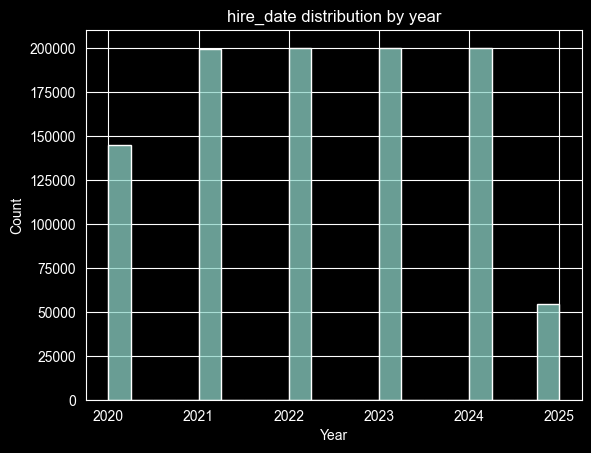


Analyzing column: birth_date
Minimum date: 1959-04-12 00:00:00
Maximum date: 2007-04-10 00:00:00


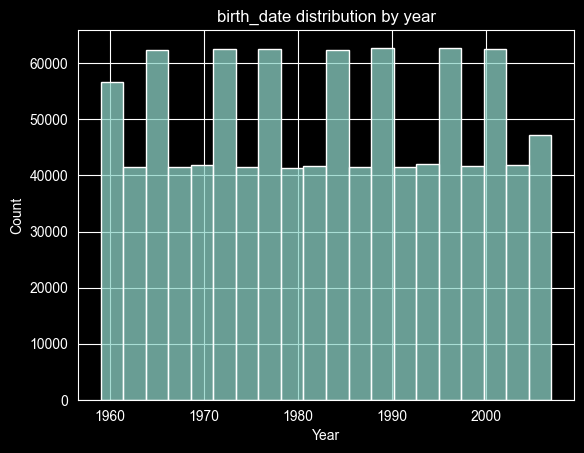


Analyzing column: last_review_date
Minimum date: 2020-04-14 00:00:00
Maximum date: 2025-04-10 00:00:00


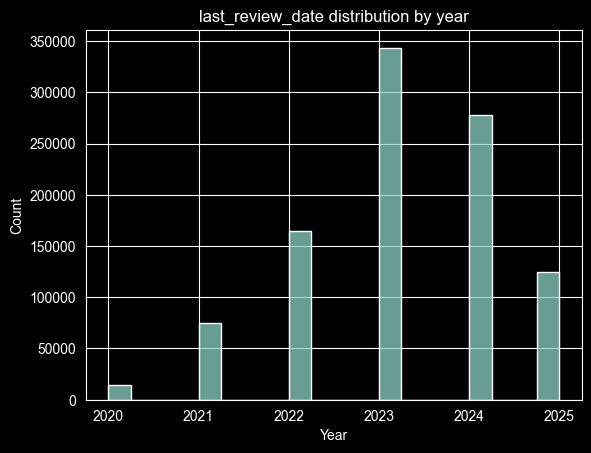

In [8]:
# =========================
# 🎯 Column groups
# =========================
id_cols = ['employee_id', 'email', 'ssn', 'bank_account', 'phone_number']

categorical_cols = [
    'department', 'job_title', 'status', 'gender',
    'education', 'employee_level', 'work_location',
    'shift', 'country', 'state'
]

text_cols = ['first_name', 'last_name', 'city', 'address']

date_cols = ['hire_date', 'birth_date', 'last_review_date']


# =========================
# 🔴 IDENTIFIER ANALYSIS
# =========================
print("\n===== IDENTIFIER COLUMNS ANALYSIS =====")

for col in id_cols:
    unique_ratio = df_small[col].nunique() / len(df_small)

    print(f"\nColumn: {col}")
    print(f"Unique ratio: {unique_ratio:.4f}")

    # Show sample values
    print("Sample values:", df_small[col].head(3).tolist())


# =========================
# 🟡 CATEGORICAL ANALYSIS
# =========================
def analyze_categorical(df, column, top_n=10):
    """
    Analyze a categorical column by displaying frequency distribution
    and plotting the top N categories.

    Parameters:
    df (DataFrame): Input dataset
    column (str): Column name to analyze
    top_n (int): Number of top categories to display
    """

    print(f"\n===== ANALYZING: {column.upper()} =====")

    # Normalized frequency (%)
    counts = df[column].value_counts(normalize=True) * 100

    print("Top categories (%):")
    print(counts.head(top_n))

    print(f"Total unique values: {df[column].nunique()}")

    # Plot
    plt.figure(figsize=(8,4))
    sns.barplot(x=counts.head(top_n).values, y=counts.head(top_n).index)
    plt.title(f"{column} distribution (%)")
    plt.xlabel("Percentage")
    plt.ylabel(column)
    plt.show()


for col in categorical_cols:
    analyze_categorical(df_small, col)


# =========================
# 🔵 TEXT DATA ANALYSIS
# =========================
print("\n===== TEXT COLUMNS ANALYSIS =====")

for col in text_cols:
    print(f"\nColumn: {col}")

    unique_count = df_small[col].nunique()
    print(f"Unique values: {unique_count}")

    print("Top 10 most frequent values:")
    print(df_small[col].value_counts().head(10))


# =========================
# 📅 DATE ANALYSIS
# =========================
print("\n===== DATE COLUMNS ANALYSIS =====")

for col in date_cols:
    print(f"\nAnalyzing column: {col}")

    # Convert to datetime
    df_small[col] = pd.to_datetime(df_small[col])

    print("Minimum date:", df_small[col].min())
    print("Maximum date:", df_small[col].max())

    # Extract year
    df_small[f'{col}_year'] = df_small[col].dt.year

    # Plot distribution by year
    plt.figure()
    sns.histplot(df_small[f'{col}_year'], bins=20)
    plt.title(f"{col} distribution by year")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.show()

# 🔍 Exploratory Data Analysis — Employee Dataset

## 1. Identifier Columns Analysis

| Column | Unique Ratio | Observation |
|---|---|---|
| `employee_id` | 1.0000 | Perfectly unique. Format: `EMP` + 10 digits. Synthetically generated. |
| `email` | 0.2975 | Not unique — multiple employees share the same email. Likely generated using Faker. |
| `ssn` | 0.9995 | Nearly unique (~0.05% duplicates). Format `NNN-NN-NNNN`, randomly generated numbers. |
| `bank_account` | 1.0000 | Perfectly unique. Random alphanumeric code. |
| `phone_number` | 1.0000 | Perfectly unique. Generated with Faker (multiple US formats). |

> ⚠️ **Note:** The `email` column with a ratio of 0.2975 indicates collisions — it cannot be used as a reliable identifier.

---

## 2. Categorical Columns Analysis

### 2.1 Department
- **19 unique categories**, with an almost **uniform distribution (~5.28% each)**.
- No weighting or probabilities: **flat/random generation without bias**.

### 2.2 Job Title
- **84 unique categories**, also uniformly distributed (~1.33% each).
- Generated categorically without hierarchy or apparent departmental logic.

### 2.3 Status
- **3 categories** with intentional proportions:

| Status | % |
|---|---|
| Active | ~85% |
| Inactive | ~10% |
| Leave | ~5% |

> Generated using weighted probabilities: `[85/100, 10/100, 5/100]`.

### 2.4 Gender
- **3 categories** with balanced distribution:

| Gender | % |
|---|---|
| F | ~45% |
| M | ~45% |
| Other | ~10% |

> Generated with probabilities `[45, 45, 10]`.

### 2.5 Education
- **4 categories** with a pyramidal distribution:

| Education | % |
|---|---|
| Professional | ~50% |
| Master | ~25% |
| High School | ~20% |
| PhD | ~5% |

### 2.6 Employee Level
- **3 categories** with predominance of Senior level:

| Level | % |
|---|---|
| Senior | ~60% |
| Mid | ~20% |
| Entry | ~20% |

### 2.7 Work Location
- **3 categories**:

| Location | % |
|---|---|
| Office | ~50% |
| Remote | ~30% |
| Hybrid | ~20% |

### 2.8 Shift
- **3 categories** with predominance of day shift:

| Shift | % |
|---|---|
| Day | ~60% |
| Night | ~30% |
| Flexible | ~10% |

### 2.9 Country
- **Single value:** `USA` (100%). Constant column, **no variance** — candidate for removal in modeling.

### 2.10 State
- **10 US states**, uniformly distributed (~10% each): TX, NY, FL, OH, MA, WA, CA, GA, PA, IL.
- Flat generation, not weighted by real population.

---

## 3. Text Columns Analysis

### 3.1 First Name
- **690 unique names** in a dataset of ~1M records → high repetition expected.
- Top values: Michael (22,614), David (15,546), James (14,762). Typical Faker distribution with Anglo bias.

### 3.2 Last Name
- **1,000 unique last names**. Top: Smith (21,634), Johnson (16,865). Same Faker pattern.

### 3.3 City
- **34 unique cities**. Springfield is a notable outlier (~58,505 records vs ~33,000 for others).
- Likely appears in multiple states and is overrepresented by Faker.

### 3.4 Address
- **999,812 unique values** — nearly one per row. Only a few with frequency = 2.
- Generated using Faker address, with minimal reuse.

---

## 4. Date Columns Analysis

| Column | Min | Max | Range |
|---|---|---|---|
| `hire_date` | 2020-04-10 | 2025-04-10 | Exactly 5 years |
| `birth_date` | 1959-04-12 | 2007-04-10 | ~48 years → employees aged 18 to 65 |
| `last_review_date` | 2020-04-14 | 2025-04-10 | Matches hiring range |

> The ranges of `hire_date` and `last_review_date` are aligned, which is consistent.
> `birth_date` up to 2007 implies employees around 18 years old at the lower bound — a reasonable minimum.

---

## 5. Overall Summary

| Type | Columns | Observation |
|---|---|---|
| Identifiers | `employee_id`, `bank_account`, `phone_number` | Unique and synthetic |
| Problematic | `email` | Low uniqueness ratio, not suitable as primary key |
| Weighted categorical | `status`, `gender`, `education`, `employee_level`, `shift`, `work_location` | Generated using probabilities |
| Flat categorical | `department`, `job_title`, `state` | No weighting applied |
| Constant | `country` | No variance, should be removed in modeling |
| Free text | `first_name`, `last_name`, `city`, `address` | Faker-generated, high repetition in names |
| Dates | `hire_date`, `birth_date`, `last_review_date` | Consistent and realistic ranges |


===== NUMERICAL COLUMNS ANALYSIS =====
Numerical columns detected: ['days_service', 'base_salary', 'bonus_percentage', 'zip_code', 'performance_score', 'vacation_days', 'sick_days']

===== ANALYZING: DAYS_SERVICE =====
count    1000000.000000
mean         913.850434
std          527.006826
min            1.000000
25%          458.000000
50%          914.000000
75%         1370.000000
max         1827.000000
Name: days_service, dtype: float64
Skewness: 0.0005
Kurtosis: -1.1987


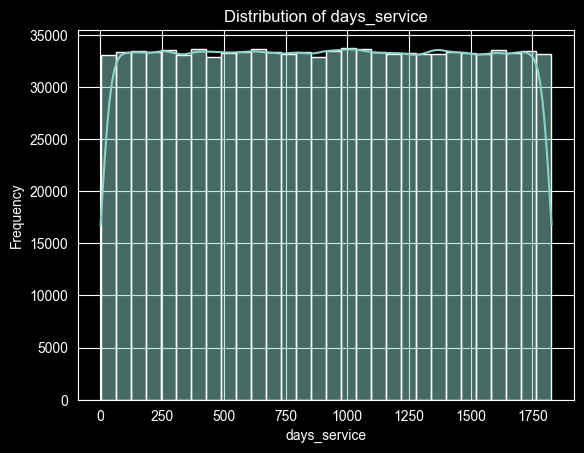

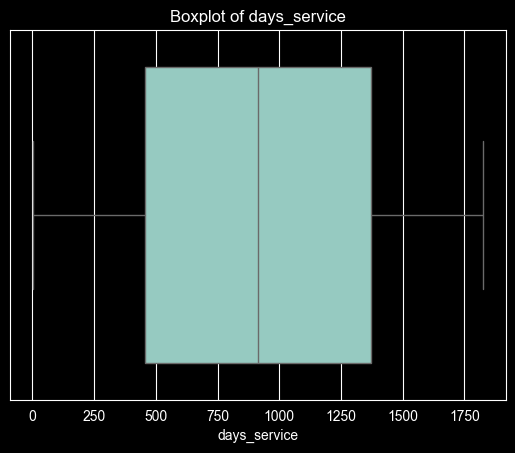


===== ANALYZING: BASE_SALARY =====
count    1000000.000000
mean       67003.721867
std        25668.545134
min        30000.000000
25%        48430.570000
50%        62302.765000
75%        80337.695000
max       200000.000000
Name: base_salary, dtype: float64
Skewness: 1.1782
Kurtosis: 2.0467


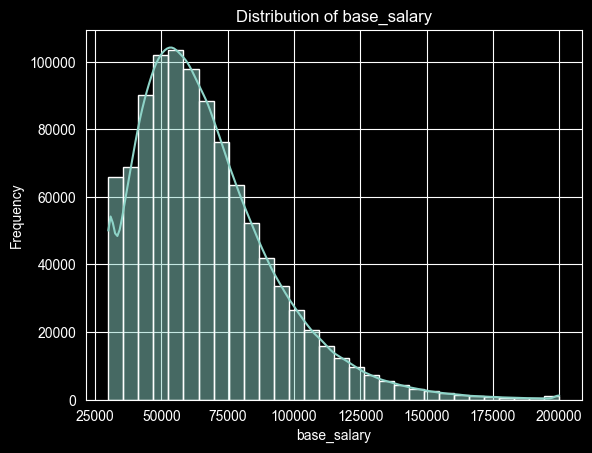

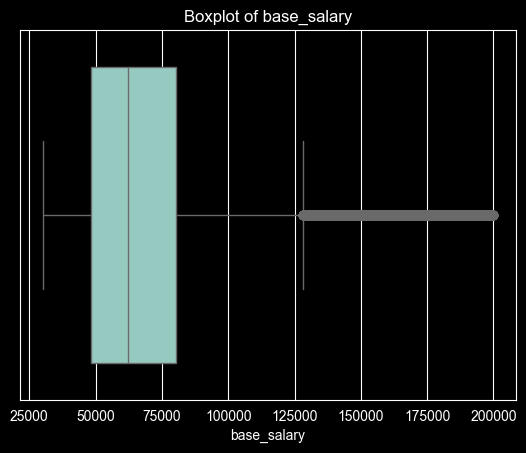


===== ANALYZING: BONUS_PERCENTAGE =====
count    1000000.000000
mean           5.006408
std            1.990524
min            0.000000
25%            3.650000
50%            5.000000
75%            6.350000
max           14.250000
Name: bonus_percentage, dtype: float64
Skewness: 0.0381
Kurtosis: -0.1215


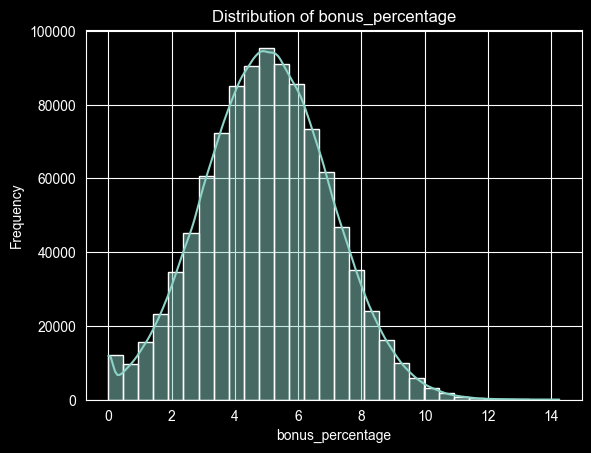

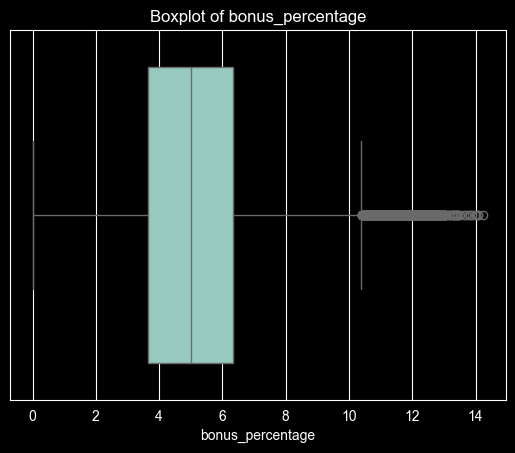


===== ANALYZING: ZIP_CODE =====
count    1000000.000000
mean       50197.807714
std        28705.279270
min          501.000000
25%        25359.000000
50%        50118.000000
75%        75029.000000
max        99950.000000
Name: zip_code, dtype: float64
Skewness: 0.0016
Kurtosis: -1.1991


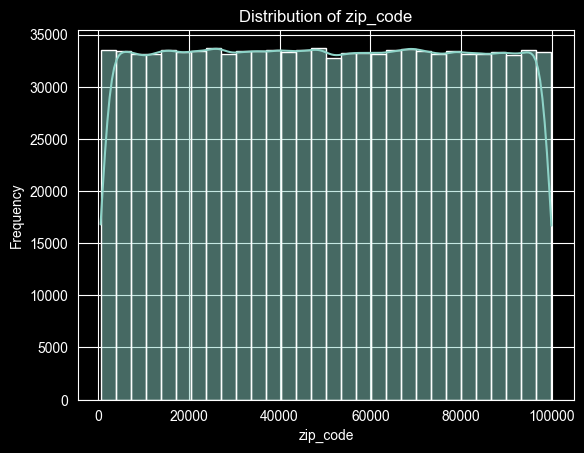

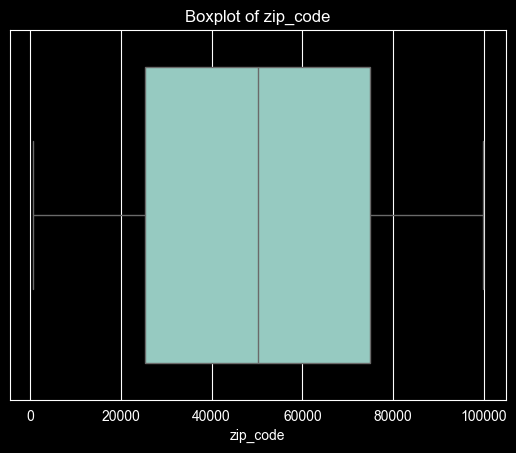


===== ANALYZING: PERFORMANCE_SCORE =====
count    1000000.000000
mean          74.988803
std            9.949680
min           26.530000
25%           68.260000
50%           75.010000
75%           81.750000
max          100.000000
Name: performance_score, dtype: float64
Skewness: -0.0411
Kurtosis: -0.1164


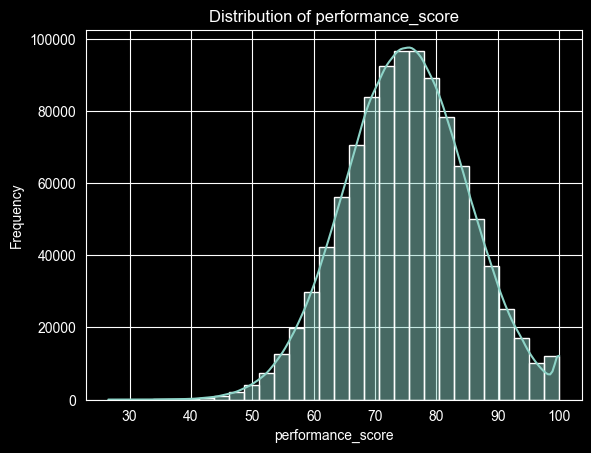

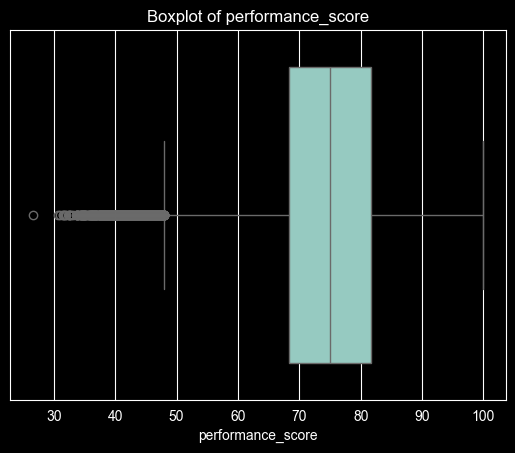


===== ANALYZING: VACATION_DAYS =====
count    1000000.000000
mean          14.999514
std            3.874181
min            1.000000
25%           12.000000
50%           15.000000
75%           18.000000
max           38.000000
Name: vacation_days, dtype: float64
Skewness: 0.2555
Kurtosis: 0.0601


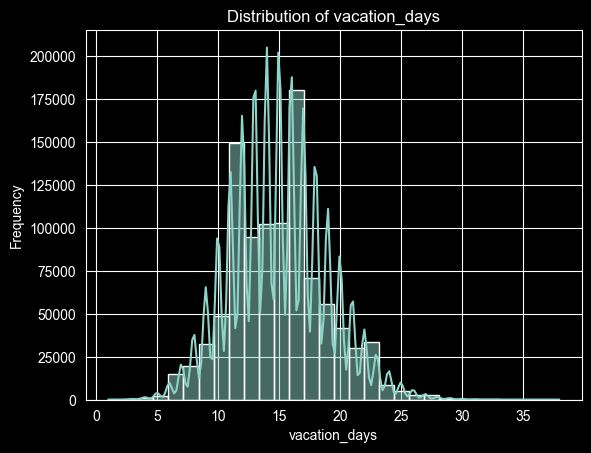

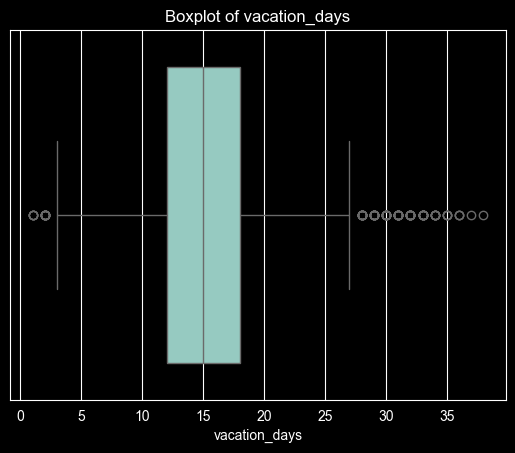


===== ANALYZING: SICK_DAYS =====
count    1000000.000000
mean           5.002378
std            2.234509
min            0.000000
25%            3.000000
50%            5.000000
75%            6.000000
max           19.000000
Name: sick_days, dtype: float64
Skewness: 0.4459
Kurtosis: 0.2014


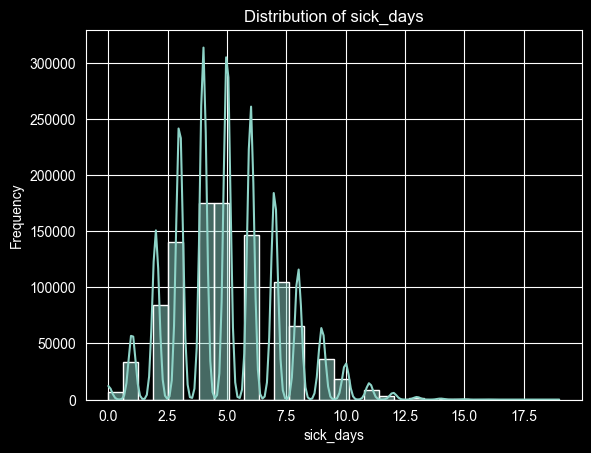

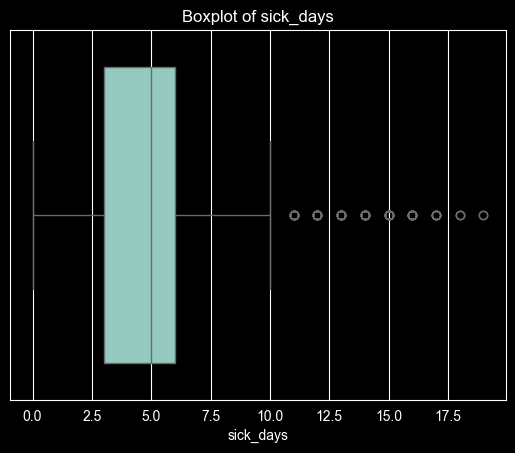

In [9]:
# =========================
# 🔢 NUMERICAL ANALYSIS
# =========================

numeric_cols = df_small.select_dtypes(include=['int64', 'float64']).columns

print("\n===== NUMERICAL COLUMNS ANALYSIS =====")
print("Numerical columns detected:", list(numeric_cols))


def analyze_numeric(df, column):
    """
    Analyze a numerical column by displaying descriptive statistics,
    distribution plots, and boxplots for outlier detection.

    Parameters:
    df (DataFrame): Input dataset
    column (str): Column name to analyze
    """

    print(f"\n===== ANALYZING: {column.upper()} =====")

    # Descriptive statistics
    print(df[column].describe())

    # Skewness and kurtosis
    skew = df[column].skew()
    kurt = df[column].kurt()

    print(f"Skewness: {skew:.4f}")
    print(f"Kurtosis: {kurt:.4f}")

    # =========================
    # 📊 Distribution plot
    # =========================
    plt.figure()
    sns.histplot(df[column], kde=True, bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

    # =========================
    # 📦 Boxplot (outliers)
    # =========================
    plt.figure()
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()


# =========================
# 🔍 Run analysis
# =========================
for col in numeric_cols:
    analyze_numeric(df_small, col)

## 6. Numerical Columns Analysis

### Summary Table

| Column | Mean | Std | Min | Max | Skewness | Kurtosis | Distribution |
|---|---|---|---|---|---|---|---|
| `days_service` | 913.85 | 527.01 | 1 | 1,827 | 0.0005 | -1.1987 | Uniform |
| `base_salary` | 67,003.72 | 25,668.55 | 30,000 | 200,000 | 1.1782 | 2.0467 | Beta / Log-normal |
| `bonus_percentage` | 5.01 | 1.99 | 0 | 14.25 | 0.0381 | -0.1215 | Normal |
| `zip_code` | 50,197.81 | 28,705.28 | 501 | 99,950 | 0.0016 | -1.1991 | Uniform |
| `performance_score` | 74.99 | 9.95 | 26.53 | 100 | -0.0411 | -0.1164 | Normal |
| `vacation_days` | 15.00 | 3.87 | 1 | 38 | 0.2555 | 0.0601 | Discrete Normal |
| `sick_days` | 5.00 | 2.23 | 0 | 19 | 0.4459 | 0.2014 | Poisson |

---

### 6.1 Days Service
- Exact range from **1 to 1,827 days** (equivalent to 0–5 years), consistent with the `hire_date` range (2020–2025).
- Skewness ≈ 0 and kurtosis ≈ -1.2 → **perfectly flat (uniform) distribution**. Each tenure day has equal probability.
- Likely generated using `randint(1, 1827)` or equivalent.

### 6.2 Base Salary
- Mean of **$67,003** with a range of $30,000–$200,000.
- **Positive skewness (1.18)** and high kurtosis (2.05) → pronounced right tail. Most employees are concentrated in low-to-mid salary ranges, with a few high-income outliers.
- Follows a **Beta or Log-normal distribution** — likely generated using a bounded asymmetric distribution.
- This is the most skewed numerical variable in the dataset.

### 6.3 Bonus Percentage
- Mean of **5%**, range from 0% to 14.25%.
- Skewness ≈ 0 and kurtosis ≈ 0 → **centered Normal distribution**.
- Likely generated using `np.random.normal(mean=5, std=2)` with clipping at 0.

### 6.4 Zip Code
- Mean ~50,197, range 501–99,950 — spans the full US ZIP code range.
- Skewness ≈ 0 and kurtosis ≈ -1.2 → **uniform distribution**, identical shape to `days_service`.
- ⚠️ **No analytical value as a numerical variable** — it is a geographic identifier and should be treated as categorical or linked with `state`/`city`.

### 6.5 Performance Score
- Mean of **74.99**, range from 26.53 to 100 (capped at 100).
- Skewness ≈ 0 and kurtosis ≈ 0 → **near-perfect Normal distribution**, centered at 75.
- Likely generated using `np.random.normal(mean=75, std=10)` with upper clipping at 100. The cap introduces a negligible negative skew.

### 6.6 Vacation Days
- Mean of **15 days**, range from 1 to 38.
- Discrete data (integers) → produces a “comb-like” effect in KDE plots.
- Slight positive skew (0.26) — right tail due to higher-benefit cases.
- Follows a **discrete Normal distribution** centered around 15 (μ ≈ 15, σ ≈ 4).
- Reflects administrative allocation with a standard policy baseline.

### 6.7 Sick Days
- Mean of **5 days**, range from 0 to 19.
- Positive skewness (0.45) → right tail with concentration at lower values.
- Discrete data with mode around 4–5 days.
- Follows a **Poisson distribution**, modeling random and infrequent events (e.g., illness) with a natural lower bound at 0.
- Intentionally contrasts with `vacation_days`: planned absence (Normal) vs. unplanned absence (Poisson).

---

### 6.8 General Observations

| Category | Columns | Notes |
|---|---|---|
| Uniform distribution | `days_service`, `zip_code` | No bias, flat random generation |
| Normal distribution | `bonus_percentage`, `performance_score`, `vacation_days` | Centered and symmetric |
| Skewed distribution | `base_salary`, `sick_days` | Right-tailed, may require transformation for linear models |
| Not suitable as numeric | `zip_code` | Should be treated as categorical/geographic |

---

## 7. General Conclusions

### 7.1 Nature of the Dataset

The exhaustive analysis of the **1,000,000 rows** and **30 columns** in this dataset confirms with a high degree of certainty that the data is **completely synthetic**. The following evidence supports this:

**Structural indicators of synthetic generation:**

* `employee_id`, `bank_account`, and `phone_number` have a uniqueness ratio exactly equal to 1.0000 — impossible in real-world data at this scale without deliberate engineering.
* `email` shows collisions (ratio 0.2975), indicating it was generated from a limited name pool using Faker, without enforcing uniqueness.
* `country` is a constant column (100% USA) with no variance — analytically useless.
* Proper names clearly originate from the Faker generator with an Anglo-Saxon bias (e.g., Michael, Smith).

**Statistical indicators of synthetic generation:**

* The **correlation between all numerical variables is practically 0**. In real data, relationships would be expected, such as: higher tenure → higher salary, better performance → higher bonus. The total absence of correlation confirms that variables were generated **completely independently**.
* Distributions are “artificially clean”: means and standard deviations are perfectly centered, lacking the noise expected in real organizational data.
* `days_service` and `zip_code` exhibit perfectly uniform distributions (kurtosis ≈ -1.2), typical of `randint()`.

---

### 7.2 Map of Detected Generation Methods

| Column                                                                           | Inferred Generation Method                           |
| -------------------------------------------------------------------------------- | ---------------------------------------------------- |
| `employee_id`                                                                    | Prefix `EMP` + 10-digit `randint`                    |
| `email`                                                                          | `Faker.email()` with limited pool → collisions       |
| `ssn`                                                                            | `randint` with format `NNN-NN-NNNN`                  |
| `bank_account`                                                                   | Custom random alphanumeric code                      |
| `phone_number`                                                                   | `Faker.phone_number()` (US)                          |
| `first_name` / `last_name`                                                       | `Faker.first_name()` / `Faker.last_name()`           |
| `address`                                                                        | `Faker.address()`                                    |
| `city`                                                                           | `Faker.city()` (Springfield overrepresented)         |
| `department` / `job_title` / `state`                                             | Flat `random.choice()` without weights               |
| `status` / `gender` / `education` / `employee_level` / `shift` / `work_location` | `random.choices()` with weighted probabilities       |
| `country`                                                                        | Hardcoded value `"USA"`                              |
| `hire_date` / `last_review_date`                                                 | Random date in range `[2020-04-10, 2025-04-10]`      |
| `birth_date`                                                                     | Random date in range `[1959, 2007]`                  |
| `days_service` / `zip_code`                                                      | `np.random.randint()` — uniform distribution         |
| `base_salary`                                                                    | Beta or log-normal distribution within `[30k, 200k]` |
| `bonus_percentage` / `performance_score`                                         | `np.random.normal()` with clipping                   |
| `vacation_days`                                                                  | Discrete `np.random.normal()` (integers)             |
| `sick_days`                                                                      | Poisson distribution                                 |

---

### 7.3 Quality of the Synthetic Dataset

| Aspect              | Evaluation                                                                                          |
| ------------------- | --------------------------------------------------------------------------------------------------- |
| Completeness        | ✅ No missing values in any column                                                                   |
| Range consistency   | ✅ Coherent dates, plausible ages                                                                    |
| Individual realism  | ✅ Each row appears to be a valid employee                                                           |
| Statistical realism | ⚠️ Zero correlations — does not reflect real organizational dynamics                                |
| ML usefulness       | ⚠️ Limited: synthetic targets will not have real predictive signal                                  |
| Problematic columns | ⚠️ `email` is not a reliable PK, `country` is constant, `zip_code` should not be treated as numeric |

---

### 7.4 Recommendations for Further Use

If this dataset is to be used for training predictive models (e.g., salary prediction, attrition, performance), the following warnings should be considered:

1. **There is no real signal between variables** — any trained model will learn noise, not patterns.
2. **Remove `country`** before any analysis or modeling.
3. **Re-encode `zip_code`** as a categorical geographic feature or remove it.
4. **Do not use `email` as a primary key** — use `employee_id` or `bank_account`.
5. **Apply a logarithmic transformation to `base_salary`** before using it in linear models due to its positive skewness (1.18).
6. The dataset is suitable for **pipeline testing, performance benchmarking, and ETL tool validation**, but not for making inferences about real human or workplace behavior.
